# LightGBMにてモデル構築から提出までの骨組みを作る


## import

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import copy
import joblib

import lightgbm as lgb
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  f1_score

plt.rcParams['font.family'] = 'MS Gothic'

# 行数と列数を設定
pd.set_option('display.max_rows', None)  # すべての行を表示
pd.set_option('display.max_columns', None)  # すべての列を表示
pd.set_option('display.max_colwidth', None)  # 各列の表示幅を制限しない

## データの読み込み

In [4]:
MODE = 'LOCAL'

if MODE == 'LOCAL':
    train = pd.read_csv('../../0_data/train.csv')
    test = pd.read_csv("../../0_data/test.csv")
    train_demo = pd.read_csv('../../0_data/train_demographics.csv')
    test_demo = pd.read_csv("../../0_data/test_demographics.csv")

    EXPORT_DIR = Path("../4_result")

if MODE == 'KAGGLE':
    import kaggle_evaluation.cmi_inference_server

    train = pd.read_csv("/kaggle/input/cmi-detect-behavior-with-sensor-data/train.csv")
    test = pd.read_csv("/kaggle/input/cmi-detect-behavior-with-sensor-data/test.csv")
    train_demo = pd.read_csv('/kaggle/input/cmi-detect-behavior-with-sensor-data/train_demographics.csv')
    test_demo = pd.read_csv("/kaggle/input/cmi-detect-behavior-with-sensor-data/test_demographics.csv")

    EXPORT_DIR = Path("./")

## データの前処理
LightGBMはNULLもいい感じに学習してくれるので，ないものはNULLのままおいておく

In [5]:
target_cols = ["gesture","sequence_type"]

def feature_engineering(df,df_demo):
    df_copy = df.copy()
    df_demo_copy = df_demo.copy()

    df_copy = df_copy.drop(columns=["orientation","behavior","phase"])
    df_set = pd.merge(df_copy, df_demo_copy, on="subject", how="left")

    df_set['acc_mag'] = np.sqrt(df_set['acc_x']**2 + df_set['acc_y']**2 + df_set['acc_z']**2)
    df_set['rot_angle'] = 2 * np.arccos(df_set['rot_w'].clip(-1, 1))

    df_set['acc_mag_jerk'] = df_set.groupby('sequence_id')['acc_mag'].diff().fillna(0)
    df_set['rot_angle_vel'] = df_set.groupby('sequence_id')['rot_angle'].diff().fillna(0)

    demographic_cols = [c for c in df_demo.columns if c not in['subject']]

    imu_cols = [c for c in df_set.columns if c.startswith('acc_')]
    imu_cols.extend([c for c in df_set.columns if c.startswith('rot_') ])
    thm_cols = [c for c in df_set.columns if c.startswith('thm_') ]
    tof_cols = [c for c in df_set.columns if c.startswith('tof_') ]

    sensor_cols = imu_cols + thm_cols + tof_cols

    aggregations = {}
    for c in sensor_cols:
        aggregations[f"{c}_mean"] = (c, 'mean')
        aggregations[f"{c}_std"] = (c, 'std')
        aggregations[f"{c}_var"] = (c, 'var')
        aggregations[f"{c}_q25"] = (c, lambda x: x.quantile(0.25))
        aggregations[f"{c}_q50"] = (c, 'median')
        aggregations[f"{c}_q75"] = (c, lambda x: x.quantile(0.75))
        aggregations[f"{c}_max"] = (c, 'max')
        aggregations[f"{c}_min"] = (c, 'min')

    for c in demographic_cols + target_cols:
        # 新しいカラム名と元のカラム名は同じ
        aggregations[c] = (c, 'first')

    df_group = df_set.groupby('sequence_id').agg(**aggregations)

    return df_group


In [22]:
def competition_metric(y_gesture, y_gesture_pred,y_bfrb, y_bfrb_pred,le):
    """
    Competition metric calculation
    """
    
    # binary_f1を計算する
    binary_f1 = f1_score(y_bfrb, y_bfrb_pred, average='binary', pos_label=1, zero_division=0)
    
    # でMacro F1を計算する
    macro_f1 = f1_score(y_gesture, y_gesture_pred, average='macro', zero_division=0)

    print("--- 混同行列 (Confusion Matrix) ---")
    # クラス名のリストを取得（行列のラベルとして使用）
    class_names = le.classes_
    # le.classes_ には文字列が入っているので、それをtransformして整数に変換する
    all_class_indices = le.transform(le.classes_)

    # 混同行列を計算
    cm = confusion_matrix(y_gesture, y_gesture_pred, labels=all_class_indices)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    # ヒートマップとして可視化
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues') # annot=Trueで数値を表示, fmt='d'で整数表示
    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('True Label (真の値)', fontsize=12)
    plt.xlabel('Predicted Label (予測した値)', fontsize=12)
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    final_score = (binary_f1 + macro_f1) / 2

    return final_score, binary_f1, macro_f1

In [ ]:
def create_model(X,y_gesture,y_bfrb,hyper_params_gesture,hyper_params_bfrb,le):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    models_gesture = []
    models_bfrb = []

    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=100)]

    # LightGBM model with cross-validation
    print("\nTraining LightGBM models with cross-validation...")
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y_gesture)):
        print(f"\nFold {fold + 1}/5")
        
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_gesture_train_fold, y_gesture_val_fold = y_gesture[train_idx], y_gesture[val_idx]
        y_bfrb_train_fold, y_bfrb_val_fold = y_bfrb[train_idx], y_bfrb[val_idx]
        
        # LightGBM model の定義
        model_gesture = lgb.LGBMClassifier(**hyper_params_gesture)
        model_bfrb = lgb.LGBMClassifier(**hyper_params_bfrb)
        
        # modelの学習
        model_gesture.fit(
            X_train_fold, y_gesture_train_fold,
            eval_set=[(X_val_fold, y_gesture_val_fold)],  
            eval_metric='multi_logloss',  
            callbacks=callbacks
        )
        model_bfrb.fit(
            X_train_fold, y_bfrb_train_fold,
            eval_set=[(X_val_fold, y_bfrb_val_fold)],  
            eval_metric='multi_logloss',  
            callbacks=callbacks
        )
        
        # Predict
        y_gesture_pred_fold = model_gesture.predict(X_val_fold)
        y_bfrb_pred_fold = model_bfrb.predict(X_val_fold)
        
        # Calculate score
        score, binary_f1, macro_f1 = competition_metric(
            y_gesture_val_fold, y_gesture_pred_fold,
            y_bfrb_val_fold, y_bfrb_pred_fold,
            le
        )
        
        cv_scores.append(score)
        models_gesture.append(model_gesture)
        models_bfrb.append(model_bfrb)

        if MODE == 'KAGGLE':
            joblib.dump(model_gesture, f'model_gesture_lgb{fold}.joblib')
            joblib.dump(model_bfrb, f'model_bfrb_lgb{fold}.joblib')

        if MODE == 'LOCAL':
            file_gesture_path = EXPORT_DIR / f'model_gesture_lgb{fold}.joblib'
            joblib.dump(model_gesture, file_gesture_path)
            file_bfrb_path = EXPORT_DIR / f'model_bfrb_lgb{fold}.joblib'
            joblib.dump(model_bfrb, file_bfrb_path)
        
        print(f"Fold {fold + 1} - Competition Score: {score:.4f} (Binary F1: {binary_f1:.4f}, Macro F1: {macro_f1:.4f})")


    print(f"\nCross-validation results:")
    print(f"Mean CV Score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores) * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

    # Train final model on all data with GPU acceleration
    print("\nTraining final model on all training data...")

    return models_gesture,models_bfrb

In [8]:
train_df = feature_engineering(train,train_demo)
train_df.loc[train_df['sequence_type'] == 'Non-Target', 'gesture'] = 'non_target'

print(train_df.shape)
train_df.head()

(8151, 2697)


acc_x_mean  acc_x_std  acc_x_var  acc_x_q25  acc_x_q50  \
sequence_id                                                           
SEQ_000007     6.153098   1.334155   1.779969   5.566406   6.488281   
SEQ_000008     3.400506   1.087142   1.181878   2.536133   3.437500   
SEQ_000013    -7.058962   1.295184   1.677501  -8.136719  -7.144531   
SEQ_000016     5.524654   1.074108   1.153709   4.703125   5.390625   
SEQ_000018     5.363715   1.627637   2.649201   5.756836   6.101562   

             acc_x_q75  acc_x_max  acc_x_min  acc_y_mean  acc_y_std  \
sequence_id                                                           
SEQ_000007    6.988281   9.015625   3.613281    3.915570   3.048287   
SEQ_000008    4.414062   5.906250   1.734375    5.311179   3.268073   
SEQ_000013   -6.222656  -3.347656  -9.250000    2.346182   2.564639   
SEQ_000016    6.234375   9.378906   3.437500   -4.408491   0.598318   
SEQ_000018    6.322266   6.832031   1.964844    4.109737   3.525304   

             acc_y_var  acc_y_q25  acc_y_q50  acc_y_q75  acc_y_max  acc_y_min  \
sequence_id                                                                     
SEQ_000007    9.292055   3.531250   5.488281   5.984375   6.519531  -2.019531   
SEQ_000008   10.680300   0.546875   7.000000   7.785156   8.667969  -0.222656   
SEQ_000013    6.577376   2.156250   3.382812   3.917969   4.683594  -3.273438   
SEQ_000016    0.357984  -4.835938  -4.492188  -3.878906  -2.960938  -5.718750   
SEQ_000018   12.427771   3.804688   6.007812   6.208984   6.718750  -3.164062   

             acc_z_mean  acc_z_std  acc_z_var  acc_z_q25  acc_z_q50  \
sequence_id                                                           
SEQ_000007     5.577782   2.337517   5.463986   3.660156   4.964844   
SEQ_000008     6.581629   2.475402   6.127617   4.470703   5.839844   
SEQ_000013    -6.068544   1.330784   1.770986  -6.617188  -5.851562   
SEQ_000016    -3.162077   6.139752  37.696554  -7.390625  -6.667969   
SEQ_000018     5.937066   2.104544   4.429107   4.426758   4.761719   

             acc_z_q75  acc_z_max  acc_z_min  acc_mag_mean  acc_mag_std  \
sequence_id                                                               
SEQ_000007    6.875000   9.792969   1.093750     10.021660     0.343905   
SEQ_000008    9.590820  11.074219   1.722656     10.018998     0.664317   
SEQ_000013   -5.277344  -3.515625 -10.945312     10.073545     0.728796   
SEQ_000016    5.937500   8.355469  -8.078125      9.906489     0.623425   
SEQ_000018    7.412109   9.933594   4.148438      9.998449     0.292560   

             acc_mag_var  acc_mag_q25  acc_mag_q50  acc_mag_q75  acc_mag_max  \
sequence_id                                                                    
SEQ_000007      0.118271     9.830380     9.974416    10.113299    11.140053   
SEQ_000008      0.441317     9.698766    10.015079    10.217095    11.575777   
SEQ_000013      0.531143     9.676183     9.994923    10.513870    12.072645   
SEQ_000016      0.388659     9.793216     9.964831    10.043816    12.711292   
SEQ_000018      0.085592     9.847799     9.941317    10.057425    11.021747   

             acc_mag_min  acc_mag_jerk_mean  acc_mag_jerk_std  \
sequence_id                                                     
SEQ_000007      9.170917           0.008242          0.475343   
SEQ_000008      7.160294          -0.042396          0.868866   
SEQ_000013      8.309325          -0.009073          1.110048   
SEQ_000016      7.889443          -0.024923          0.902724   
SEQ_000018      9.520368           0.024930          0.318009   

             acc_mag_jerk_var  acc_mag_jerk_q25  acc_mag_jerk_q50  \
sequence_id                                                         
SEQ_000007           0.225951         -0.195880          0.007397   
SEQ_000008           0.754928         -0.090650          0.004099   
SEQ_000013           1.232207         -0.572853          0.013305   
SEQ_000016           0.814910         -0.178125          0.0000

In [9]:
# target_gestures_df = train[train['sequence_type'] == 'Target']
# bfrb_gestures = target_gestures_df['gesture'].unique().tolist()

le = LabelEncoder()
y_bfrb = (train_df['sequence_type'] == 'Target')
y_gesture = le.fit_transform(train_df['gesture'])
X = train_df.drop(columns=target_cols)

if MODE == 'KAGGLE':
    joblib.dump(le, 'le.joblib')
if MODE == 'LOCAL':
    file_path = EXPORT_DIR / 'le.joblib'
    joblib.dump(le, file_path)

In [10]:
hyper_params_gesture = {
            'objective':'multiclass',
            'n_estimators':1000,
            'learning_rate':0.08,
            'max_depth':15,
            'reg_alpha':0.8,
            'lambda_l2':4.0,  
            'num_leaves':31, 
            'min_child_samples':32,
            'colsample_bytree':0.85,
            'subsample':0.5,
            'subsample_freq':0,
            'cat_smooth':20.0,
            'is_unbalance':True,
            'max_bin':127,
            'verbose':-1,  
            'metric':'multi_logloss'   
            }

hyper_params_bfrb = {
    'objective': 'binary', 
    'metric': 'binary_logloss',
    'n_estimators': 1000,
    'learning_rate': 0.08,
    'max_depth': 15,
    'num_leaves': 31, 
    'min_child_samples': 32,
    'reg_alpha': 0.8,
    'lambda_l2': 4.0, 
    'colsample_bytree': 0.85,
    'subsample': 0.5,
    'subsample_freq': 1, 
    'cat_smooth': 20.0,
    'max_bin': 127,
    'verbose': -1,
    'is_unbalance': True,               
}


Training LightGBM models with cross-validation...

Fold 1/5


C:\Users\kamim\AppData\Local\Temp\ipykernel_9496\4004757776.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_bfrb_train_fold, y_bfrb_val_fold = y_bfrb[train_idx], y_bfrb[val_idx]


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[170]	valid_0's multi_logloss: 0.770196
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[721]	valid_0's binary_logloss: 0.0650086
--- 混同行列 (Confusion Matrix) ---
--- デバッグ情報 ---
渡される y_gesture_val_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_val_fold の中身（先頭5件）: [4 8 3 0 8]
渡される y_gesture_pred_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_pred_fold の中身（先頭5件）: [4 8 3 0 8]
--------------------


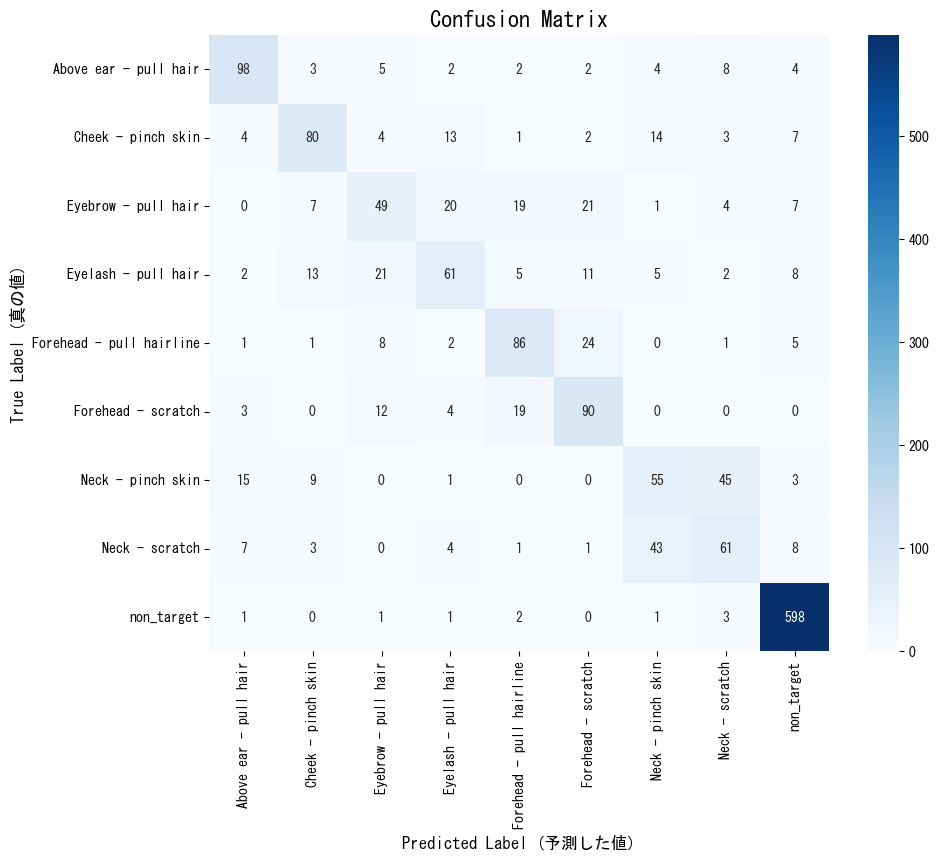

Fold 1 - Competition Score: 0.7968 (Binary F1: 0.9787, Macro F1: 0.6149)

Fold 2/5


C:\Users\kamim\AppData\Local\Temp\ipykernel_9496\4004757776.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_bfrb_train_fold, y_bfrb_val_fold = y_bfrb[train_idx], y_bfrb[val_idx]


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[244]	valid_0's multi_logloss: 0.722675
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[955]	valid_0's binary_logloss: 0.0545281
--- 混同行列 (Confusion Matrix) ---
--- デバッグ情報 ---
渡される y_gesture_val_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_val_fold の中身（先頭5件）: [1 4 8 6 6]
渡される y_gesture_pred_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_pred_fold の中身（先頭5件）: [8 5 8 6 6]
--------------------


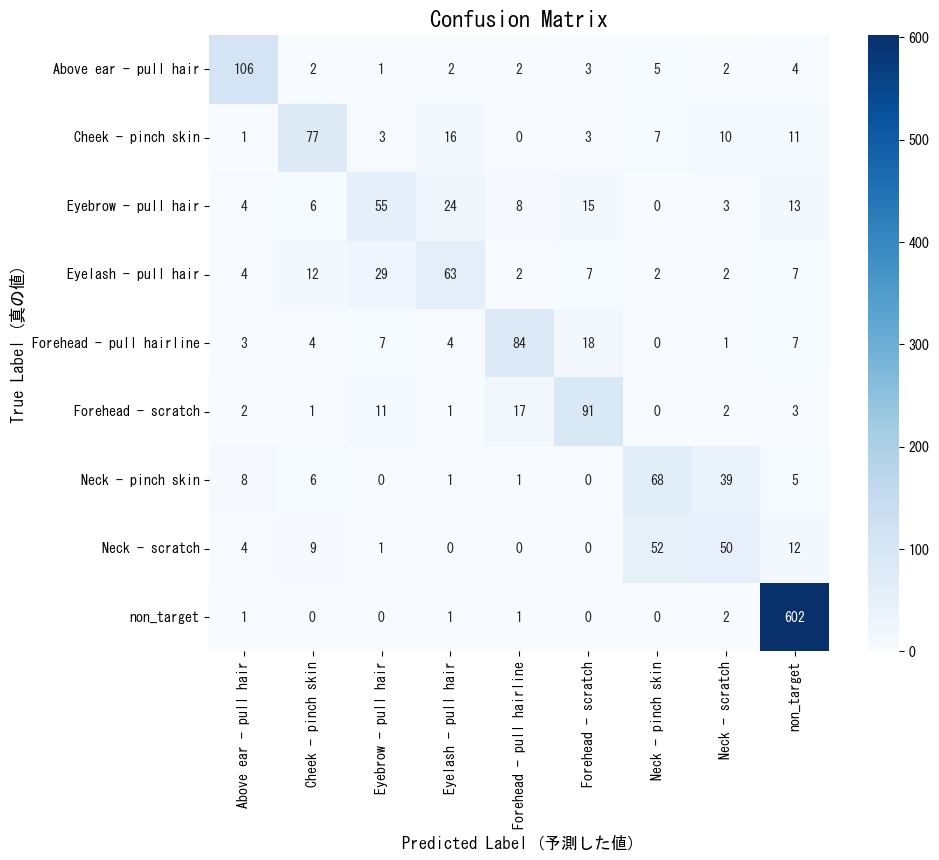

Fold 2 - Competition Score: 0.8083 (Binary F1: 0.9834, Macro F1: 0.6333)

Fold 3/5


C:\Users\kamim\AppData\Local\Temp\ipykernel_9496\4004757776.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_bfrb_train_fold, y_bfrb_val_fold = y_bfrb[train_idx], y_bfrb[val_idx]


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[162]	valid_0's multi_logloss: 0.783081
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[606]	valid_0's binary_logloss: 0.0689104
--- 混同行列 (Confusion Matrix) ---
--- デバッグ情報 ---
渡される y_gesture_val_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_val_fold の中身（先頭5件）: [1 3 0 8 5]
渡される y_gesture_pred_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_pred_fold の中身（先頭5件）: [1 3 8 8 5]
--------------------


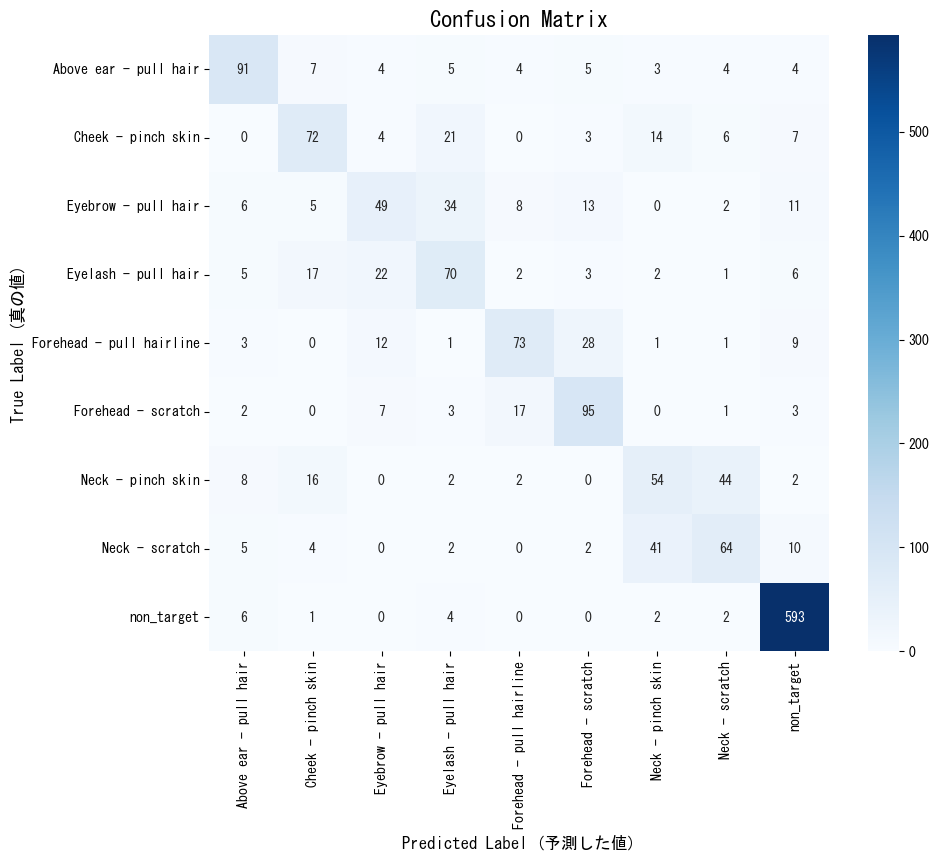

Fold 3 - Competition Score: 0.7915 (Binary F1: 0.9771, Macro F1: 0.6059)

Fold 4/5


C:\Users\kamim\AppData\Local\Temp\ipykernel_9496\4004757776.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_bfrb_train_fold, y_bfrb_val_fold = y_bfrb[train_idx], y_bfrb[val_idx]


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[181]	valid_0's multi_logloss: 0.752344
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[583]	valid_0's binary_logloss: 0.06271
--- 混同行列 (Confusion Matrix) ---
--- デバッグ情報 ---
渡される y_gesture_val_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_val_fold の中身（先頭5件）: [5 6 2 8 6]
渡される y_gesture_pred_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_pred_fold の中身（先頭5件）: [2 7 3 8 7]
--------------------


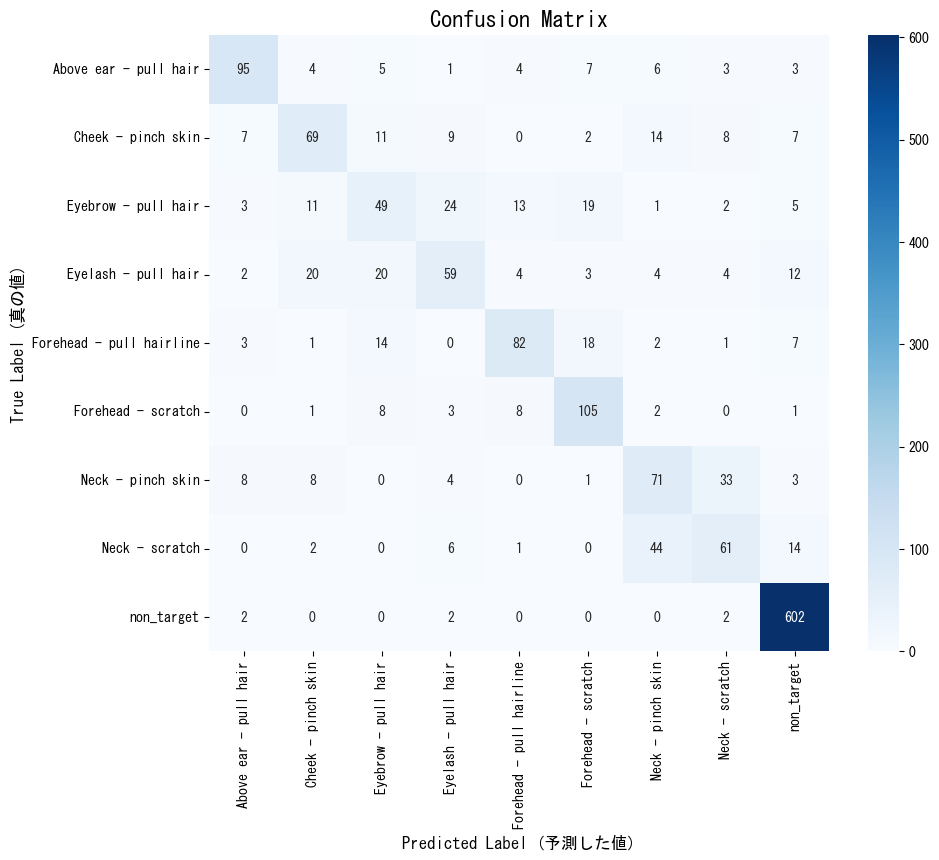

Fold 4 - Competition Score: 0.8060 (Binary F1: 0.9833, Macro F1: 0.6287)

Fold 5/5


C:\Users\kamim\AppData\Local\Temp\ipykernel_9496\4004757776.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_bfrb_train_fold, y_bfrb_val_fold = y_bfrb[train_idx], y_bfrb[val_idx]


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[205]	valid_0's multi_logloss: 0.748691
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[937]	valid_0's binary_logloss: 0.0571032
--- 混同行列 (Confusion Matrix) ---
--- デバッグ情報 ---
渡される y_gesture_val_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_val_fold の中身（先頭5件）: [7 4 2 8 4]
渡される y_gesture_pred_fold の型: <class 'numpy.ndarray'>
渡される y_gesture_pred_fold の中身（先頭5件）: [6 4 2 8 4]
--------------------


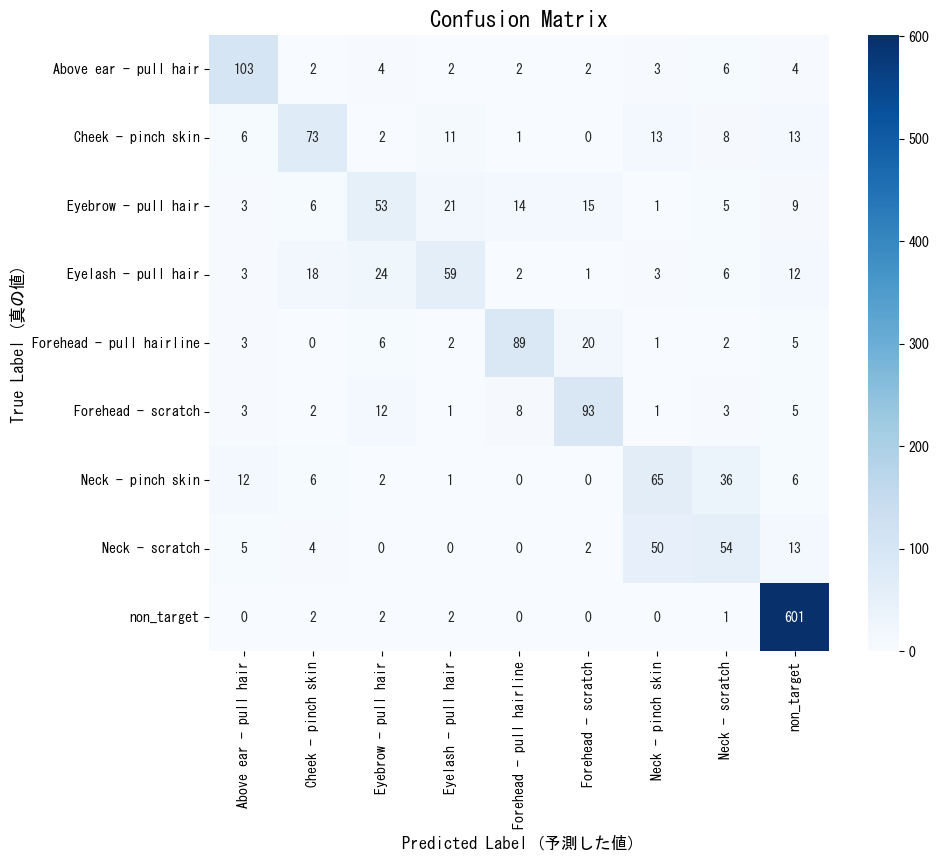

Fold 5 - Competition Score: 0.8073 (Binary F1: 0.9848, Macro F1: 0.6298)

Cross-validation results:
Mean CV Score: 0.8020 (+/- 0.0133)
Individual fold scores: [0.796796756955115, 0.8083480435072146, 0.7914840297092862, 0.8060330923938098, 0.8072768199523352]

Training final model on all training data...


In [21]:
models_gesture,models_bfrb = create_model(
    X,y_gesture,y_bfrb,
    hyper_params_gesture,hyper_params_bfrb,
    le
    )

In [ ]:
def feature_engineering_inf(df,df_demo):
    df_copy = df.copy()
    df_demo_copy = df_demo.copy()

    df_set = pd.merge(df_copy, df_demo_copy, on="subject", how="left")

    df_set['acc_mag'] = np.sqrt(df_set['acc_x']**2 + df_set['acc_y']**2 + df_set['acc_z']**2)
    df_set['rot_angle'] = 2 * np.arccos(df_set['rot_w'].clip(-1, 1))

    df_set['acc_mag_jerk'] = df_set.groupby('sequence_id')['acc_mag'].diff().fillna(0)
    df_set['rot_angle_vel'] = df_set.groupby('sequence_id')['rot_angle'].diff().fillna(0)

    demographic_cols = [c for c in df_demo.columns if c not in['subject']]

    imu_cols = [c for c in df_set.columns if c.startswith('acc_')]
    imu_cols.extend([c for c in df_set.columns if c.startswith('rot_') ])
    thm_cols = [c for c in df_set.columns if c.startswith('thm_') ]
    tof_cols = [c for c in df_set.columns if c.startswith('tof_') ]

    sensor_cols = imu_cols + thm_cols + tof_cols

    aggregations = {}
    for c in sensor_cols:
        aggregations[f"{c}_mean"] = (c, 'mean')
        aggregations[f"{c}_std"] = (c, 'std')
        aggregations[f"{c}_var"] = (c, 'var')
        aggregations[f"{c}_q25"] = (c, lambda x: x.quantile(0.25))
        aggregations[f"{c}_q50"] = (c, 'median')
        aggregations[f"{c}_q75"] = (c, lambda x: x.quantile(0.75))
        aggregations[f"{c}_max"] = (c, 'max')
        aggregations[f"{c}_min"] = (c, 'min')

    for c in demographic_cols:
        # 新しいカラム名と元のカラム名は同じ
        aggregations[c] = (c, 'first')

    df_group = df_set.groupby('sequence_id').agg(**aggregations)

    return df_group

In [ ]:
def predict(sequence: pd.DataFrame, demographics: pd.DataFrame) -> str:
    
    test_df = feature_engineering_inf(sequence,demographics)

    # --- ステップ1: BFRBか否かを2値分類モデルで予測 ---
    bfrb_predictions = []
    for model in models_bfrb:
        # 予測値は 0 (Non-Target) または 1 (Target)
        pred = model.predict(test_df)
        
        # 配列で返ってきた場合も、最初の値を取得
        if isinstance(pred, np.ndarray):
            pred = pred[0]
        bfrb_predictions.append(int(pred))
    # アンサンブルの多数決で最終的な2値分類の予測を決定
    final_bfrb_pred = max(set(bfrb_predictions), key=bfrb_predictions.count)

    # もし「非BFRB (0)」と予測された場合
    if final_bfrb_pred == 0:
        # その時点で 'non_target' を返して処理を終了
        return 'non_target'
    
    else:
        # 多クラス分類モデル（models_gesture）で、どのBFRBかを予測する
        gesture_predictions = []
        for model in models_gesture:
            # 予測値はジェスチャーのID (0, 1, 2, ...)
            pred = model.predict(test_df)
            
            if isinstance(pred, np.ndarray):
                pred = pred[0]
            gesture_predictions.append(int(pred))
        
        # アンサンブルの多数決で最終的なジェスチャーIDを決定
        predicted_label_id = max(set(gesture_predictions), key=gesture_predictions.count)
        
        # LabelEncoderを使って、IDを元のジェスチャー名（文字列）に変換
        predicted_gesture_str = le.inverse_transform([predicted_label_id])[0]
        
        return predicted_gesture_str

In [ ]:
predict(test,test_demo)

'non_target'